# Variables de entrada y variable objetivo

Anticipar si un equipo industrial presentará una falla durante el día siguiente. El objetivo será organizar correctamente `X` e `y`, distinguir variables numéricas, categóricas e identificadores, y detectar columnas que contienen información posterior a la falla.

## Objetivos del cuaderno

Al finalizar este cuaderno, deberías poder:

- distinguir las variables de entrada de la variable objetivo;
- construir `X` e `y` a partir de un DataFrame;
- reconocer variables numéricas, categóricas e identificadores;
- analizar señales relacionadas con una falla;
- revisar cuándo está disponible cada dato;
- detectar un caso claro de fuga de datos.

## 1. Importar las librerías

Usaremos `pandas` para organizar los datos y `matplotlib` para crear una visualización sencilla. No se requieren archivos externos ni paquetes especiales, por lo que el cuaderno puede ejecutarse directamente en Google Colab.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## 2. Conocer el problema y los datos

Supongamos que el área de mantenimiento quiere anticipar qué equipos fallarán durante el día siguiente. La predicción se realizaría al finalizar la jornada actual.

Cada fila representa una revisión de un equipo. Algunas columnas describen su estado antes de la predicción y otras fueron registradas después de confirmarse una falla. Estas últimas nos permitirán estudiar un error frecuente.

In [2]:
datos = {
    "equipo_id": list(range(501, 525)),
    "horas_operacion": [820, 210, 640, 155, 910, 330, 720, 280, 875, 450, 190, 760,
                         590, 260, 980, 370, 680, 230, 840, 510, 300, 790, 610, 410],
    "temperatura_media_c": [58, 74, 61, 79, 55, 70, 60, 76, 57, 66, 81, 59,
                               63, 73, 54, 68, 62, 78, 56, 64, 75, 60, 65, 72],
    "vibracion_mm_s": [1.8, 4.9, 2.1, 5.8, 1.5, 4.2, 2.4, 5.1, 1.7, 3.3, 6.2, 2.0,
                          2.8, 4.6, 1.4, 3.9, 2.5, 5.5, 1.6, 3.0, 4.8, 2.2, 3.1, 4.0],
    "mantenimientos_ultimos_6_meses": [0, 2, 0, 3, 0, 1, 0, 2, 0, 1, 3, 0,
                                           1, 2, 0, 1, 0, 3, 0, 1, 2, 0, 1, 2],
    "tipo_equipo": ["Bomba", "Compresor", "Bomba", "Motor", "Bomba", "Compresor",
                     "Motor", "Compresor", "Bomba", "Motor", "Compresor", "Bomba",
                     "Motor", "Compresor", "Bomba", "Motor", "Bomba", "Compresor",
                     "Bomba", "Motor", "Compresor", "Bomba", "Motor", "Compresor"],
    "turno": ["Día", "Noche", "Día", "Noche", "Día", "Noche", "Día", "Noche",
              "Día", "Día", "Noche", "Día", "Día", "Noche", "Día", "Noche",
              "Día", "Noche", "Día", "Día", "Noche", "Día", "Día", "Noche"],
    "falla_proximo_dia": ["No", "Sí", "No", "Sí", "No", "Sí", "No", "Sí",
                              "No", "No", "Sí", "No", "No", "Sí", "No", "Sí",
                              "No", "Sí", "No", "No", "Sí", "No", "No", "Sí"],
    "fecha_reparacion": [None, "2026-06-08", None, "2026-06-03", None, "2026-06-17",
                           None, "2026-06-11", None, None, "2026-06-06", None, None, "2026-06-20",
                           None, "2026-06-14", None, "2026-06-09", None, None, "2026-06-23", None, None, "2026-06-28"],
    "componente_danado": [None, "Sello", None, "Rodamiento", None, "Válvula", None, "Sello",
                           None, None, "Rodamiento", None, None, "Válvula", None, "Sello",
                           None, "Rodamiento", None, None, "Válvula", None, None, "Sello"]
}

df = pd.DataFrame(datos)
df.head(8)

,equipo_id,horas_operacion,temperatura_media_c,vibracion_mm_s,mantenimientos_ultimos_6_meses,tipo_equipo,turno,falla_proximo_dia,fecha_reparacion,componente_danado
0,501,820,58,1.8,0,Bomba,Día,No,None,None
1,502,210,74,4.9,2,Compresor,Noche,Sí,2026-06-08,Sello
2,503,640,61,2.1,0,Bomba,Día,No,None,None
3,504,155,79,5.8,3,Motor,Noche,Sí,2026-06-03,Rodamiento
4,505,910,55,1.5,0,Bomba,Día,No,None,None
5,506,330,70,4.2,1,Compresor,Noche,Sí,2026-06-17,Válvula
6,507,720,60,2.4,0,Motor,Día,No,None,None
7,508,280,76,5.1,2,Compresor,Noche,Sí,2026-06-11,Sello


Las primeras filas muestran horas de operación, mediciones del equipo y contexto del turno. También aparecen `fecha_reparacion` y `componente_danado`, que solo tienen valores cuando la falla ya ocurrió. Que una columna esté disponible en la tabla histórica no significa que sea una entrada válida para una predicción.

Antes de seleccionar columnas, revisemos la estructura general del DataFrame: cantidad de filas, columnas, tipos de datos y valores no nulos.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 10 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   equipo_id                       24 non-null     int64  
 1   horas_operacion                 24 non-null     int64  
 2   temperatura_media_c             24 non-null     int64  
 3   vibracion_mm_s                  24 non-null     float64
 4   mantenimientos_ultimos_6_meses  24 non-null     int64  
 5   tipo_equipo                     24 non-null     object 
 6   turno                           24 non-null     object 
 7   falla_proximo_dia               24 non-null     object 
 8   fecha_reparacion                10 non-null     object 
 9   componente_danado               10 non-null     object 
dtypes: float64(1), int64(4), object(5)
memory usage: 2.0+ KB


El dataset contiene 24 revisiones y 10 columnas. `fecha_reparacion` y `componente_danado` tienen menos valores no nulos porque solo se completaron después de una falla. Esta diferencia refleja el momento en que se genera la información.

## 3. Definir la variable objetivo: `y`

La pregunta del proyecto es: **¿el equipo fallará durante el día siguiente?**

La columna que responde esa pregunta es `falla_proximo_dia`. Por lo tanto, esa será nuestra variable objetivo.

In [4]:
y = df["falla_proximo_dia"]
y.head(8)

,falla_proximo_dia
0,No
1,Sí
2,No
3,Sí
4,No
5,Sí
6,No
7,Sí


`y` es una Serie con una respuesta para cada revisión. Como sus valores son `Sí` y `No`, estamos planteando un problema de clasificación.

Aunque `y` contiene la respuesta histórica, no debe formar parte de `X`: al predecir una revisión nueva será justamente el dato desconocido.

In [5]:
y.value_counts()

,count
falla_proximo_dia,
No,14
Sí,10


En este conjunto hay más revisiones sin falla que revisiones con falla. Por ahora solo registramos esa diferencia; más adelante será importante al separar y evaluar los datos.

## 4. Elegir variables de entrada: `X`

Para una primera selección usaremos información disponible al finalizar la jornada: horas de operación, temperatura, vibración, mantenimientos recientes, tipo de equipo y turno.

Dejaremos fuera el identificador, la variable objetivo y las dos columnas generadas después de la falla.

In [6]:
columnas_entrada = [
    "horas_operacion",
    "temperatura_media_c",
    "vibracion_mm_s",
    "mantenimientos_ultimos_6_meses",
    "tipo_equipo",
    "turno",
]

X = df[columnas_entrada]
X.head()

,horas_operacion,temperatura_media_c,vibracion_mm_s,mantenimientos_ultimos_6_meses,tipo_equipo,turno
0,820,58,1.8,0,Bomba,Día
1,210,74,4.9,2,Compresor,Noche
2,640,61,2.1,0,Bomba,Día
3,155,79,5.8,3,Motor,Noche
4,910,55,1.5,0,Bomba,Día


`X` es un DataFrame con varias columnas. Cada fila describe la misma revisión que ocupa esa posición en `y`, pero sin incluir la respuesta que queremos predecir. La lista `columnas_entrada` hace explícita la decisión de qué información podrá aprender el modelo.

In [7]:
print(f"Forma de X: {X.shape}")
print(f"Cantidad de valores en y: {y.shape[0]}")
print(f"¿Los índices coinciden?: {X.index.equals(y.index)}")

Forma de X: (24, 6)
Cantidad de valores en y: 24
¿Los índices coinciden?: True


`X` tiene 24 filas y 6 columnas, mientras que `y` tiene 24 respuestas. Los índices coinciden, así que cada fila conserva su correspondencia con la respuesta de la misma revisión.

## 5. Reconocer el tipo y el papel de cada variable

Los tipos almacenados por `pandas` ofrecen una primera pista, pero no reemplazan la interpretación del significado de cada columna.

In [8]:
df.dtypes.to_frame(name="tipo_en_pandas")

,tipo_en_pandas
equipo_id,int64
horas_operacion,int64
temperatura_media_c,int64
vibracion_mm_s,float64
mantenimientos_ultimos_6_meses,int64
tipo_equipo,object
turno,object
falla_proximo_dia,object
fecha_reparacion,object
componente_danado,object


`equipo_id` aparece como entero, pero solo identifica registros. En cambio, `horas_operacion` también es entero y sí representa una cantidad medible. `falla_proximo_dia` aparece como texto, pero su papel especial proviene de la pregunta del proyecto: es el objetivo.

In [9]:
papel_columnas = pd.DataFrame({
    "columna": df.columns,
    "tipo_conceptual": [
        "Identificador", "Numérica", "Numérica", "Numérica", "Numérica",
        "Categórica", "Categórica", "Categórica", "Fecha posterior",
        "Categórica posterior"
    ],
    "papel_en_el_proyecto": [
        "Excluir de X", "Entrada posible", "Entrada posible", "Entrada posible",
        "Entrada posible", "Entrada posible", "Entrada posible",
        "Variable objetivo (y)", "Excluir por fuga", "Excluir por fuga"
    ]
})
papel_columnas

,columna,tipo_conceptual,papel_en_el_proyecto
0,equipo_id,Identificador,Excluir de X
1,horas_operacion,Numérica,Entrada posible
2,temperatura_media_c,Numérica,Entrada posible
3,vibracion_mm_s,Numérica,Entrada posible
4,mantenimientos_ultimos_6_meses,Numérica,Entrada posible
5,tipo_equipo,Categórica,Entrada posible
6,turno,Categórica,Entrada posible
7,falla_proximo_dia,Categórica,Variable objetivo (y)
8,fecha_reparacion,Fecha posterior,Excluir por fuga
9,componente_danado,Categórica posterior,Excluir por fuga


La tabla separa cómo se almacena una columna, qué significa y qué papel tendrá. Una columna numérica no es automáticamente una buena feature, y una columna disponible en el DataFrame no es automáticamente válida para `X`.

In [10]:
variables_numericas = X.select_dtypes(include="number").columns.tolist()
variables_categoricas = X.select_dtypes(exclude="number").columns.tolist()

print("Variables numéricas:", variables_numericas)
print("Variables categóricas:", variables_categoricas)

Variables numéricas: ['horas_operacion', 'temperatura_media_c', 'vibracion_mm_s', 'mantenimientos_ultimos_6_meses']
Variables categóricas: ['tipo_equipo', 'turno']


La selección contiene cuatro variables numéricas y dos categóricas. Reconocer la diferencia es importante porque los distintos tipos suelen requerir preparaciones diferentes antes de entrenar un modelo.

## 6. Buscar señales relacionadas con el objetivo

Podemos hacer una primera observación comparando los promedios de las variables numéricas entre revisiones con y sin falla. Esta comparación no demuestra causalidad ni garantiza que un modelo vaya a predecir bien.

In [11]:
resumen_por_falla = (
    df.groupby("falla_proximo_dia")[variables_numericas]
      .mean()
      .round(2)
)
resumen_por_falla

,horas_operacion,temperatura_media_c,vibracion_mm_s,mantenimientos_ultimos_6_meses
falla_proximo_dia,,,,
No,726.79,60.0,2.24,0.29
Sí,273.50,74.6,4.90,2.10


En este conjunto, las revisiones con falla muestran en promedio mayor temperatura y vibración, además de más mantenimientos recientes. Son señales posibles; el dataset es pequeño y fue construido para practicar la organización de variables.

In [12]:
falla_por_tipo = pd.crosstab(
    df["tipo_equipo"],
    df["falla_proximo_dia"],
    normalize="index"
).mul(100).round(1)
falla_por_tipo

falla_proximo_dia,No,Sí
tipo_equipo,,
Bomba,100.0,0.0
Compresor,0.0,100.0
Motor,71.4,28.6


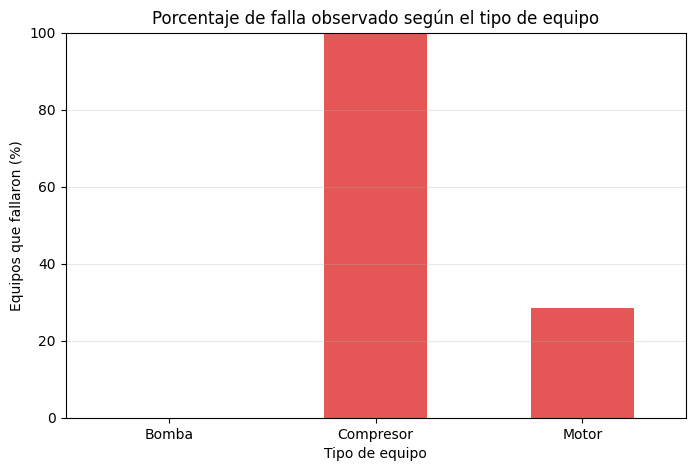

In [13]:
falla_por_tipo["Sí"].plot(kind="bar", color="#E45756", figsize=(8, 5))
plt.title("Porcentaje de falla observado según el tipo de equipo")
plt.xlabel("Tipo de equipo")
plt.ylabel("Equipos que fallaron (%)")
plt.xticks(rotation=0)
plt.ylim(0, 100)
plt.grid(axis="y", alpha=0.3)
plt.show()

En estos datos, los compresores presentan un porcentaje de falla mayor que los otros tipos. Es una variable razonable para investigar, pero no prueba que el tipo de equipo cause la falla ni que la relación se mantenga fuera de esta muestra.

## 7. Revisar cuándo está disponible cada dato

Una relación fuerte con el objetivo no alcanza para aceptar una variable. También debemos preguntar qué sabemos al finalizar la jornada y qué conocemos recién después de confirmarse la falla.

In [14]:
disponibilidad = pd.DataFrame({
    "columna": df.columns,
    "momento_disponible": ["Antes"] * 7 + ["Después"] * 3,
    "decision": [
        "Excluir: identificador", "Puede integrar X", "Puede integrar X", "Puede integrar X",
        "Puede integrar X", "Puede integrar X", "Puede integrar X", "Es y",
        "Excluir de X", "Excluir de X"
    ]
})
disponibilidad

,columna,momento_disponible,decision
0,equipo_id,Antes,Excluir: identificador
1,horas_operacion,Antes,Puede integrar X
2,temperatura_media_c,Antes,Puede integrar X
3,vibracion_mm_s,Antes,Puede integrar X
4,mantenimientos_ultimos_6_meses,Antes,Puede integrar X
5,tipo_equipo,Antes,Puede integrar X
6,turno,Antes,Puede integrar X
7,falla_proximo_dia,Después,Es y
8,fecha_reparacion,Después,Excluir de X
9,componente_danado,Después,Excluir de X


Las seis variables elegidas para `X` están disponibles antes de la predicción. `falla_proximo_dia` se conoce después y funciona como `y`. La fecha de reparación y el componente dañado también se conocen después, pero son consecuencias del resultado y deben excluirse.

El identificador existe antes, pero queda afuera porque ubica al equipo y no describe un patrón que esperemos generalizar.

## 8. Detectar una fuga de datos

Imaginemos que seleccionamos todas las columnas excepto el objetivo y el identificador. Incluiríamos `fecha_reparacion` y `componente_danado`. El código funcionaría, pero la decisión sería incorrecta. Veamos qué relación tiene la existencia de una reparación con la falla.

In [15]:
tiene_fecha_reparacion = df["fecha_reparacion"].notna().map({True: "Sí", False: "No"})
pd.crosstab(
    tiene_fecha_reparacion,
    y,
    rownames=["Tiene fecha de reparación"],
    colnames=["Falla próximo día"]
)

Falla próximo día,No,Sí
Tiene fecha de reparación,,
No,14,0
Sí,0,10


La tabla muestra una coincidencia total: todos los equipos con fecha de reparación pertenecen a la clase `Sí`, y todos los que no tienen fecha pertenecen a `No`.

La relación es engañosa porque la fecha se registra cuando la falla ya ocurrió. Un sistema que intente anticiparla al finalizar la jornada todavía no dispondrá de ese dato. Incluirla en `X` sería una fuga de datos.

In [16]:
columnas_incorrectas = columnas_entrada + ["fecha_reparacion", "componente_danado"]
comparacion_selecciones = pd.DataFrame({
    "seleccion": ["X incorrecta", "X válida"],
    "cantidad_columnas": [len(columnas_incorrectas), len(columnas_entrada)],
    "incluye_informacion_posterior": ["Sí", "No"]
})
comparacion_selecciones

,seleccion,cantidad_columnas,incluye_informacion_posterior
0,X incorrecta,8,Sí
1,X válida,6,No


La selección incorrecta tiene más columnas, pero no es mejor. La fuga de datos no siempre produce un error de Python; para detectarla necesitamos conocer el significado de cada columna y el momento en que se genera.

## 9. Construir la selección final

Después de revisar el objetivo, los tipos de variables y su disponibilidad temporal, construimos la versión final de `X` e `y`.

In [17]:
X_final = df[columnas_entrada].copy()
y_final = df["falla_proximo_dia"].copy()

pd.concat([X_final.head(), y_final.head()], axis=1)

,horas_operacion,temperatura_media_c,vibracion_mm_s,mantenimientos_ultimos_6_meses,tipo_equipo,turno,falla_proximo_dia
0,820,58,1.8,0,Bomba,Día,No
1,210,74,4.9,2,Compresor,Noche,Sí
2,640,61,2.1,0,Bomba,Día,No
3,155,79,5.8,3,Motor,Noche,Sí
4,910,55,1.5,0,Bomba,Día,No


La tabla vuelve a mostrar juntas las entradas y la respuesta para verificar su correspondencia, pero en el código quedaron almacenadas por separado. La selección es válida para el problema planteado; las categorías y otras transformaciones se trabajarán más adelante.

## Actividad breve

Modificá la lista `columnas_actividad`. Conservá solamente columnas que puedan funcionar como entradas válidas. Después ejecutá la celda y compará tu selección con `columnas_entrada`.

In [18]:
columnas_actividad = [
    "horas_operacion",
    "temperatura_media_c",
    "vibracion_mm_s",
    "mantenimientos_ultimos_6_meses",
    "tipo_equipo",
    "turno",
]
X_actividad = df[columnas_actividad]

print("Columnas seleccionadas:")
print(X_actividad.columns.tolist())
print("\n¿Coinciden con la selección válida?:", set(columnas_actividad) == set(columnas_entrada))

Columnas seleccionadas:
['horas_operacion', 'temperatura_media_c', 'vibracion_mm_s', 'mantenimientos_ultimos_6_meses', 'tipo_equipo', 'turno']

¿Coinciden con la selección válida?: True


Si agregás `equipo_id`, `fecha_reparacion`, `componente_danado` o `falla_proximo_dia`, la selección dejará de coincidir con la propuesta válida. Las razones no son idénticas: una es un identificador, dos contienen información posterior y la última es el target.

## Cierre del cuaderno

En este cuaderno separamos un DataFrame en variables de entrada y variable objetivo para anticipar fallas de equipos. Vimos que `X` no debe construirse tomando todas las columnas disponibles: cada feature necesita una justificación vinculada con el problema, su significado y el momento en que estará disponible.

También distinguimos variables numéricas, categóricas e identificadores y observamos señales asociadas con la falla sin confundir asociación con causalidad. Finalmente, detectamos una fuga de datos: `fecha_reparacion` y `componente_danado` revelaban información posterior. La selección final quedó organizada, pero todavía no dividimos los datos ni transformamos sus columnas.

## Para pensar

1. ¿Qué diferencia hay entre la información almacenada en `X` y la almacenada en `y`?
2. ¿Por qué `equipo_id` no es una buena variable predictora aunque esté guardado como número?
3. ¿Qué diferencia hay entre el tipo con el que `pandas` almacena una columna y su tipo conceptual?
4. ¿Por qué una relación clara con el target no alcanza para aceptar una variable como feature?
5. ¿Qué pregunta temporal ayuda a detectar una posible fuga de datos?
6. ¿Por qué una selección con más columnas puede ser peor que otra con menos columnas?